In [1]:
%load_ext autoreload
%autoreload 2

Failed to read module file 'C:\Users\Victor\AppData\Local\Programs\Python\Python312\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\Victor\Desktop\Université\Research\qml-quansistor-entropy\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Victor\Desktop\Université\Research\qml-quansistor-entropy\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Victor\AppData\Local\Programs\Python\Python312\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>

In [2]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [3]:
import logging

import torch
from qqe.src.experiments.plotting import view_correlation
import pandas as pd

from scripts import (
    generate_dataset,
    generate_pred_datasets,
    optuna_search,
    predictions,
    training,
)
from src.utils import configure_logger

logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

# Generate datasets

In [ ]:
backend = "pennylane"  # "pennylane" | "qiskit" | "cirq"
target = "SRE"
method = "fwht"
output_dir = "/outputs/data/identity/training_data"
n_bins = 50
families = "random"
n_seeds = 150

In [6]:
generate_dataset(
    backend=backend,
    target=target,
    method=method,
    use_dask=True,
    output_dir="/outputs/data/general_dataset",
    n_bins_option=n_bins,
    families=families,
    n_seeds_option=n_seeds,
    prediction_n_seeds_option=50,
    qubits_min=4,
    qubits_max=30,
    qubits_step=2,
    layers_min=2,
    layers_max=100,
    layers_step=2,
    target_qubits = "4,6,8,10",
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="32GiB",
)

2026-05-12 14:46:53,530 - qqe.src.GNN.dataset_builder - INFO - Processing family: random
2026-05-12 14:46:53,939 - qqe.src.GNN.dataset_builder - INFO - Generated 124950 configs for random
2026-05-12 14:46:54,300 - qqe.src.parallel.dask - INFO - Creating local Dask cluster with 4 workers, 1 threads per worker.
2026-05-12 14:46:54,732 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-05-12 14:46:54,758 - distributed.scheduler - INFO - State start
2026-05-12 14:46:54,780 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:64473
2026-05-12 14:46:54,781 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:8787/status
2026-05-12 14:46:54,782 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-05-12 14:46:54,808 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 32GiB due to system memory limit of 31.19 GiB
2026-0

### Identity-like

In [4]:
from qqe.src.GNN.dataset_builder import SamplingConfig, RegimeDistribution

In [ ]:
backend = "pennylane"  # "pennylane" | "qiskit" | "cirq"
target = "SRE"
method = "fwht"
output_dir = "/outputs/data/identity/training_data"
n_bins = 50
families = "random"
n_seeds = 175

sampling_config = SamplingConfig(
    clifford=RegimeDistribution(
        regimes=["zero", "low", "medium", "high"],
        probabilities=[0.15, 0.15, 0.25, 0.45],
    ),
    random=RegimeDistribution(
        regimes=["identity_like", "clifford_like", "small_angles", "generic"],
        probabilities=[1.0, 0.0, 0.0, 0.0],
    ),
    quansistor=RegimeDistribution(
        regimes=["identity_like", "weak", "moderate", "structured_equal_ab", "structured_opposite_ab", "generic_uniform"],
        probabilities=[0.10, 0.20, 0.25, 0.15, 0.15, 0.15],
    ),
    haar=RegimeDistribution(
        regimes=["none", "sparse_weak", "dense_weak", "sparse_full", "medium", "full"],
        probabilities=[0.10, 0.20, 0.20, 0.15, 0.20, 0.15],
    ),
)

In [14]:
output_path = Path(output_dir)
print(f"Output path: {output_path}")

Output path: \outputs\data\training_data\identity


In [ ]:
generate_dataset(
    backend=backend,
    target=target,
    method=method,
    use_dask=True,
    output_dir=output_dir,
    n_bins_option=n_bins,
    families=families,
    n_seeds_option=n_seeds,
    qubits_min=4,
    qubits_max=10,
    qubits_step=2,
    layers_min=2,
    layers_max=100,
    layers_step=2,
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
)

2026-05-12 13:44:44,693 - qqe.src.GNN.dataset_builder - INFO - Processing family: random
2026-05-12 13:44:44,844 - qqe.src.GNN.dataset_builder - INFO - Generated 10200 configs for random
2026-05-12 13:44:44,890 - qqe.src.parallel.dask - INFO - Creating local Dask cluster with 4 workers, 1 threads per worker.
c:\Users\Victor\Desktop\Université\Research\qml-quansistor-entropy\.venv\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 60093 instead
  warnings.warn(
2026-05-12 13:44:46,877 - distributed.scheduler - INFO - State start
2026-05-12 13:44:47,695 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:53581
2026-05-12 13:44:47,704 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:60093/status
2026-05-12 13:44:47,782 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-05-12 13:44:48,313 - distributed.nanny - INFO -         S

KeyboardInterrupt: 

2026-05-12 13:45:30,140 - distributed.scheduler - INFO - Register worker addr: tcp://127.0.0.1:53652 name: 0
2026-05-12 13:45:30,240 - distributed.scheduler - INFO - Starting worker compute stream, tcp://127.0.0.1:53652
2026-05-12 13:45:30,246 - distributed.core - INFO - Starting established connection to tcp://127.0.0.1:53657
2026-05-12 13:45:30,295 - distributed.scheduler - INFO - Register worker addr: tcp://127.0.0.1:53658 name: 1
2026-05-12 13:45:30,297 - distributed.scheduler - INFO - Starting worker compute stream, tcp://127.0.0.1:53658
2026-05-12 13:45:30,298 - distributed.core - INFO - Starting established connection to tcp://127.0.0.1:53660
2026-05-12 13:45:30,445 - distributed.scheduler - INFO - Register worker addr: tcp://127.0.0.1:53648 name: 3
2026-05-12 13:45:30,446 - distributed.scheduler - INFO - Starting worker compute stream, tcp://127.0.0.1:53648
2026-05-12 13:45:30,447 - distributed.core - INFO - Starting established connection to tcp://127.0.0.1:53653
2026-05-12 13

In [6]:
n_seeds = 50
output_dir = "/outputs/data/identity/prediction_data"

True

In [7]:
generate_pred_datasets(
    backend=backend,
    method="none",
    use_dask=True,
    output_dir=output_dir,
    n_bins_option=n_bins,
    families=families,
    sampling_config=sampling_config,
    n_seeds_option=n_seeds,
    qubits_min=12,
    qubits_max=30,
    qubits_step=2,
    layers_min=2,
    layers_max=100,
    layers_step=2,
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
)

2026-05-12 13:59:07,209 - qqe.src.GNN.dataset_builder - INFO - Processing family: random
2026-05-12 13:59:07,252 - qqe.src.GNN.dataset_builder - INFO - Generated 25500 configs for random
2026-05-12 13:59:07,513 - qqe.src.parallel.dask - INFO - Creating local Dask cluster with 4 workers, 1 threads per worker.
2026-05-12 13:59:07,838 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-05-12 13:59:07,861 - distributed.scheduler - INFO - State start
2026-05-12 13:59:07,865 - distributed.diskutils - INFO - Found stale lock file and directory 'C:\\Users\\Victor\\AppData\\Local\\Temp\\dask-scratch-space\\scheduler-6cwpwal9', purging
2026-05-12 13:59:07,866 - distributed.diskutils - INFO - Found stale lock file and directory 'C:\\Users\\Victor\\AppData\\Local\\Temp\\dask-scratch-space\\scheduler-797hkhxf', purging
2026-05-12 13:59:07,868 - distributed.diskutils - INFO - Found stale loc

SystemExit: 

c:\Users\Victor\Desktop\Université\Research\qml-quansistor-entropy\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
backend = "pennylane"  # "pennylane" | "qiskit" | "cirq"
target = "SRE"
method = "fwht"
output_dir = "/outputs/data/generic/training_data"
n_bins = 50
families = "random"
n_seeds = 100

sampling_config = SamplingConfig(
    clifford=RegimeDistribution(
        regimes=["zero", "low", "medium", "high"],
        probabilities=[0.15, 0.15, 0.25, 0.45],
    ),
    random=RegimeDistribution(
        regimes=["identity_like", "clifford_like", "small_angles", "generic"],
        probabilities=[0.0, 0.0, 0.0, 1.0],
    ),
    quansistor=RegimeDistribution(
        regimes=["identity_like", "weak", "moderate", "structured_equal_ab", "structured_opposite_ab", "generic_uniform"],
        probabilities=[0.10, 0.20, 0.25, 0.15, 0.15, 0.15],
    ),
    haar=RegimeDistribution(
        regimes=["none", "sparse_weak", "dense_weak", "sparse_full", "medium", "full"],
        probabilities=[0.10, 0.20, 0.20, 0.15, 0.20, 0.15],
    ),
)

In [ ]:
generate_dataset(
    backend=backend,
    target=target,
    method=method,
    use_dask=True,
    output_dir=output_dir,
    n_bins_option=n_bins,
    families=families,
    sampling_config=sampling_config,
    n_seeds_option=n_seeds,
    qubits_min=4,
    qubits_max=10,
    qubits_step=2,
    layers_min=2,
    layers_max=100,
    layers_step=2,
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
)

# Training

In [4]:
import ast

def to_scalar(x):
    # Already numeric
    if isinstance(x, (int, float)):
        return x

    # torch / numpy scalar
    if hasattr(x, "item"):
        return x.item()

    # Strings
    if isinstance(x, str):
        x = x.strip()

        # Handle tensor(...) by stripping wrapper FIRST
        if x.startswith("tensor(") and x.endswith(")"):
            x = x[len("tensor("):-1].strip()

        try:
            val = ast.literal_eval(x)
        except Exception:
            # fallback: plain float string
            return float(x)

        # If it's a list/tuple like [10]
        if isinstance(val, (list, tuple)):
            if len(val) == 1:
                return float(val[0])
            raise ValueError(f"Unexpected list length: {val}")

        return float(val)

    raise ValueError(f"Unsupported type: {type(x)}")

In [5]:
def run(
    model_type,
    epochs,
    lr,
    loss_type,
    batch_size,
    training_mode,
    family,
    target,
    model_hparams,
    train_hparams,
    training_data_dir,
    model_save_path,
):
    training(
        epochs=epochs,
        lr=lr,
        loss_type=loss_type,
        batch_size=batch_size,
        training_mode=training_mode,
        family=family,
        target=target,
        model_type=model_type,
        model_hparams=model_hparams,
        train_hparams=train_hparams,
        training_data_dir=training_data_dir,
        model_save_path=model_save_path,
        show_progress=True,
        show_val_progress=False,
        log_every_n_batches=10,
        heartbeat_secs=60.0,
        epoch_time_warning_secs=600.0,
    )
    training_scope = "family" if training_mode == "per_family" else "global"
    predictions(
        model_path=model_save_path,
        model_kind=model_type,
        training_scope=training_scope,
        loss_type=loss_type,
        model_family=family,
        dataset_root=training_data_dir,
        dataset_family=family,
        batch_size=batch_size,
        global_feature_variant="binned",
        node_feature_backend_variant=None,
        plot_n_layers=10,
        plot_n_qubits=18,
        split_by_family=True,
        show_progress=True,
    )

    df = pd.read_csv(f"../outputs/predictions/{training_scope}/{model_type}_predictions_{family}.csv")
    cols_to_fix = ["n_qubits", "n_layers", "seed"]

    for col in cols_to_fix:
        df[col] = df[col].apply(to_scalar).astype(int)
    view_correlation(
        df,
        nq=10,
        nl=80,
        col_x="target",
        col_y="prediction",
    )

### GNN

In [18]:
model_type="gnn"
epochs = 30
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/identity_dataset"
model_save_path = "../outputs/models/identity_random_gnn.pt"

In [ ]:
default_model_hparams = {
    "gnn_hidden": 32,
    "gnn_heads": 4,
    "global_hidden": 128,
    "reg_hidden": 128,
    "num_layers": 2,
    "dropout_rate": 0.10,
}

default_train_hparams = {
    "weight_decay": 0.00025,
    "grad_clip": 0.04,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

In [ ]:
training(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_type=model_type,
    model_hparams=default_model_hparams,
    train_hparams=default_train_hparams,
    training_data_dir=data_dir,
    model_save_path=model_save_path,
    show_progress=True,
    show_val_progress=False,
    log_every_n_batches=10,
    heartbeat_secs=60.0,
    epoch_time_warning_secs=600.0,
)

2026-05-14 12:44:29,951 - qqe.src.GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=huber
2026-05-14 12:44:29,952 - qqe.src.GNN.training.runners - INFO - Training configuration done.
2026-05-14 12:44:29,953 - qqe.src.GNN.training.runners - INFO - Collecting data paths...
2026-05-14 12:46:59,450 - qqe.src.GNN.training.runners - INFO - Found 35700 data paths.
2026-05-14 12:46:59,451 - qqe.src.GNN.training.runners - INFO - Data paths collected.
2026-05-14 12:46:59,451 - qqe.src.GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-05-14 12:48:59,417 - qqe.src.GNN.training.runners - INFO - Loaders and model built.
2026-05-14 12:48:59,418 - qqe.src.GNN.training.runners - INFO - Starting training...
2026-05-14 12:48:59,422 - qqe.src.GNN.training.train - INFO - -------- EPOCH 001 --------


Epoch 1/30:  66%|██████▌   | 530/804 [01:00<00:27, 10.07it/s, loss=0.0001, graphs=17024]

2026-05-14 12:49:59,428 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 532/804 | loss 0.000119 | elapsed 60.0s | graphs 17024


2026-05-14 12:50:32,447 - qqe.src.GNN.training.train - INFO - Training complete (93.0s) | running validation...


2026-05-14 12:50:41,535 - qqe.src.GNN.training.train - INFO - Losses | train 0.000098 | val 0.000029 | lr 1.00e-04 | time train=93.0s val=9.1s total=102.1s
2026-05-14 12:50:41,537 - qqe.src.GNN.training.train - INFO - -------- EPOCH 002 --------


...

Epoch 16/30:  61%|██████    | 491/804 [01:00<00:36,  8.58it/s, loss=0.0000, graphs=15744]

2026-05-14 13:16:32,727 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 16 batch 492/804 | loss 0.000034 | elapsed 60.0s | graphs 15744


2026-05-14 13:17:11,443 - qqe.src.GNN.training.train - INFO - Training complete (98.8s) | running validation...


2026-05-14 13:17:20,545 - qqe.src.GNN.training.train - INFO - Losses | train 0.000035 | val 0.000028 | lr 1.00e-04 | time train=98.8s val=9.1s total=107.9s
2026-05-14 13:17:20,546 - qqe.src.GNN.training.train - INFO - -------- EPOCH 017 --------


KeyboardInterrupt: 

In [7]:
predictions(
    model_path="../outputs/models/gnn_huber_random.pt",
    model_kind="gnn",
    training_scope="family",
    loss_type="huber",
    model_family="random",
    dataset_root=data_dir,
    dataset_family="random",
    batch_size=32,
    global_feature_variant="binned"
    ,
    node_feature_backend_variant=None,
    plot_n_layers=10,
    plot_n_qubits=18,
    split_by_family=True,
    show_progress=True,
)

2026-05-13 13:51:29,929 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/gnn_huber_random.pt
2026-05-13 13:52:01,788 - scripts.predictions - INFO - Found 124950 prediction files
Predicting (gnn): 100%|██████████| 3905/3905 [11:30<00:00,  5.66batch/s]
2026-05-13 14:03:41,428 - scripts.predictions - INFO - Saved 124950 predictions to ../outputs/predictions/family/gnn_predictions_random.csv
2026-05-13 14:03:41,623 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/family/gnn_pred_layers_random.png
2026-05-13 14:03:41,837 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/family/gnn_pred_qubits_random.png


In [10]:
df = pd.read_csv("../outputs/predictions/family/gnn_predictions_random.csv")

In [ ]:
cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    df[col] = df[col].apply(to_scalar).astype(int)

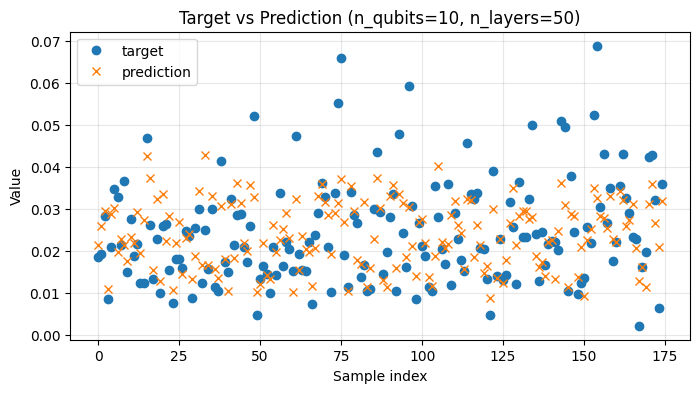

Pearson r = 0.7113


: 

In [ ]:
view_correlation(
    df,
    nq=10,
    nl=50,
    col_x="target",
    col_y="prediction",
)

### NN

In [4]:
model_type="nn"
epochs = 25
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/identity_dataset"

In [5]:
default_model_hparams = {
    "hidden_dim": 128,
    "dropout_rate": 0.0,
}

default_train_hparams = {
    "weight_decay": 1e-3,
    "grad_clip": 5.0,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

2026-05-14 10:01:02,475 - qqe.src.GNN.training.runners - INFO - Starting training | model_type=nn | training_mode=per_family | family=random | loss_type=huber
2026-05-14 10:01:02,478 - qqe.src.GNN.training.runners - INFO - Training configuration done.
2026-05-14 10:01:02,478 - qqe.src.GNN.training.runners - INFO - Collecting data paths...
2026-05-14 10:03:09,561 - qqe.src.GNN.training.runners - INFO - Found 35700 data paths.
2026-05-14 10:03:09,563 - qqe.src.GNN.training.runners - INFO - Data paths collected.
2026-05-14 10:03:09,563 - qqe.src.GNN.training.runners - INFO - Building loaders and model for model_type=nn...
2026-05-14 10:03:43,540 - qqe.src.GNN.training.runners - INFO - Loaders and model built.
2026-05-14 10:03:43,542 - qqe.src.GNN.training.runners - INFO - Starting training...
2026-05-14 10:03:43,721 - qqe.src.GNN.training.train - INFO - -------- EPOCH 001 --------


Using device: cuda
                                                                                        

2026-05-14 10:04:34,845 - qqe.src.GNN.training.train - INFO - Training complete (51.1s) | running validation...


2026-05-14 10:04:39,655 - qqe.src.GNN.training.train - INFO - Losses | train 0.000071 | val 0.000037 | lr 1.00e-04 | time train=51.1s val=4.8s total=55.9s
2026-05-14 10:04:39,658 - qqe.src.GNN.training.train - INFO - -------- EPOCH 002 --------


2026-05-14 10:05:32,568 - qqe.src.GNN.training.train - INFO - Training complete (52.9s) | running validation...


...

2026-05-14 10:14:32,626 - qqe.src.GNN.training.train - INFO - Losses | train 0.000032 | val 0.000028 | lr 5.00e-05 | time train=56.5s val=6.0s total=62.5s
2026-05-14 10:14:32,627 - qqe.src.GNN.training.train - INFO - -------- EPOCH 012 --------


2026-05-14 10:15:29,310 - qqe.src.GNN.training.train - INFO - Training complete (56.7s) | running validation...


2026-05-14 10:15:35,260 - qqe.src.GNN.training.train - INFO - Losses | train 0.000032 | val 0.000030 | lr 5.00e-05 | time train=56.7s val=5.9s total=62.6s
2026-05-14 10:15:35,261 - qqe.src.GNN.training.train - INFO - -------- EPOCH 013 --------


2026-05-14 10:16:34,844 - qqe.src.GNN.training.train - INFO - Training complete (59.6s) | running validation...


2026-05-14 10:16:40,978 - qqe.src.GNN.training.train - INFO - Losses | train 0.000032 | val 0.000029 | lr 5.00e-05 | time train=59.6s val=6.1s total=65.7s
2026-05-14 10:16:40,979 - qqe.src.GNN.training.train - INFO - Early stopping at epoch 013 | best val 0.000026 | patience exhausted (10/10)
2026-05-14 10:16:59,830 - qqe.src.GNN.training.runners - INFO - Training complete.


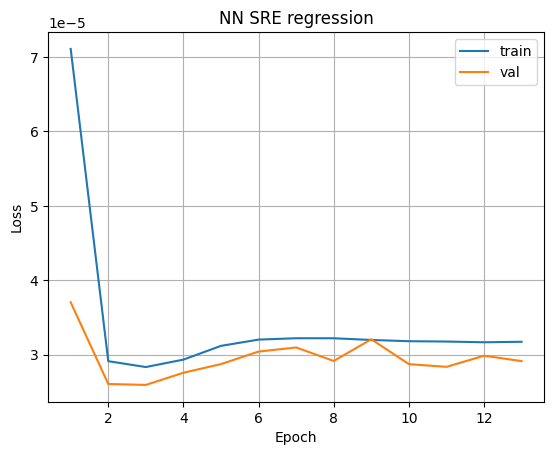

2026-05-14 10:17:00,053 - qqe.src.GNN.training.runners - INFO - Saved model checkpoint to ..\outputs\models\nn_huber_random.pt
2026-05-14 10:17:00,057 - scripts.train_model - INFO - Final test loss: 0.000027


In [6]:
training(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_type=model_type,
    model_hparams=default_model_hparams,
    train_hparams=default_train_hparams,
    training_data_dir=data_dir,
    show_progress=True,
    show_val_progress=False,
    log_every_n_batches=10,
    heartbeat_secs=60.0,
    epoch_time_warning_secs=600.0,
)

In [7]:
predictions(
    model_path="../outputs/models/nn_huber_random.pt",
    model_kind="nn",
    training_scope="family",
    loss_type="huber",
    model_family="random",
    dataset_root=data_dir,
    dataset_family="random",
    batch_size=32,
    global_feature_variant="binned"
    ,
    node_feature_backend_variant=None,
    plot_n_layers=10,
    plot_n_qubits=18,
    split_by_family=True,
    show_progress=True,
)

2026-05-14 10:17:35,029 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/nn_huber_random.pt
2026-05-14 10:18:13,319 - scripts.predictions - INFO - Found 124950 prediction files
Predicting (nn): 100%|██████████| 3905/3905 [03:36<00:00, 18.04batch/s]
2026-05-14 10:21:50,306 - scripts.predictions - INFO - Saved 124950 predictions to ../outputs/predictions/family/nn_predictions_random.csv
2026-05-14 10:21:50,443 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/family/nn_pred_layers_random.png
2026-05-14 10:21:50,582 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/family/nn_pred_qubits_random.png


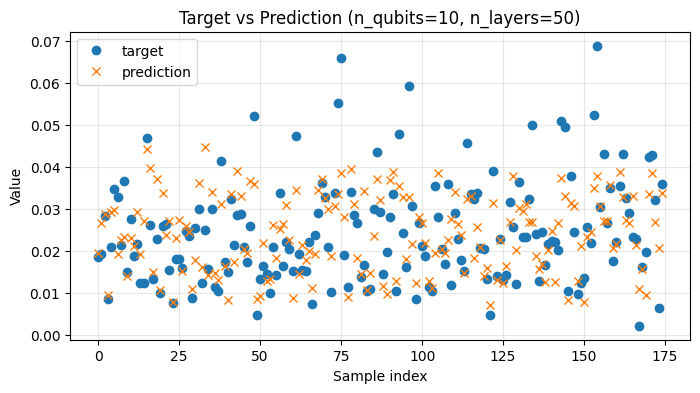

Pearson r = 0.7254


In [11]:
df = pd.read_csv("../outputs/predictions/family/nn_predictions_random.csv")

cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    df[col] = df[col].apply(to_scalar).astype(int)

view_correlation(
    df,
    nq=10,
    nl=50,
    col_x="target",
    col_y="prediction",
)

In [12]:
model_type="nn"
epochs = 25
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/general_dataset"

default_model_hparams = {
    "hidden_dim": 128,
    "dropout_rate": 0.0,
}

default_train_hparams = {
    "weight_decay": 1e-3,
    "grad_clip": 5.0,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

2026-05-14 10:23:05,156 - qqe.src.GNN.training.runners - INFO - Starting training | model_type=nn | training_mode=per_family | family=random | loss_type=huber
2026-05-14 10:23:05,157 - qqe.src.GNN.training.runners - INFO - Training configuration done.
2026-05-14 10:23:05,157 - qqe.src.GNN.training.runners - INFO - Collecting data paths...
2026-05-14 10:25:26,726 - qqe.src.GNN.training.runners - INFO - Found 35700 data paths.
2026-05-14 10:25:26,727 - qqe.src.GNN.training.runners - INFO - Data paths collected.
2026-05-14 10:25:26,727 - qqe.src.GNN.training.runners - INFO - Building loaders and model for model_type=nn...
2026-05-14 10:26:04,970 - qqe.src.GNN.training.runners - INFO - Loaders and model built.
2026-05-14 10:26:04,970 - qqe.src.GNN.training.runners - INFO - Starting training...
2026-05-14 10:26:04,973 - qqe.src.GNN.training.train - INFO - -------- EPOCH 001 --------


Using device: cuda
                                                                                        

2026-05-14 10:27:01,584 - qqe.src.GNN.training.train - INFO - Training complete (56.6s) | running validation...


2026-05-14 10:27:07,528 - qqe.src.GNN.training.train - INFO - Losses | train 0.642020 | val 0.128034 | lr 1.00e-04 | time train=56.6s val=5.9s total=62.6s
2026-05-14 10:27:07,529 - qqe.src.GNN.training.train - INFO - -------- EPOCH 002 --------


2026-05-14 10:28:04,463 - qqe.src.GNN.training.train - INFO - Training complete (56.9s) | running validation...


...

2026-05-14 10:50:40,827 - qqe.src.GNN.training.train - INFO - Losses | train 0.028657 | val 0.036597 | lr 1.00e-04 | time train=57.2s val=6.0s total=63.2s
2026-05-14 10:50:40,827 - qqe.src.GNN.training.train - INFO - -------- EPOCH 024 --------


2026-05-14 10:51:38,034 - qqe.src.GNN.training.train - INFO - Training complete (57.2s) | running validation...


2026-05-14 10:51:44,033 - qqe.src.GNN.training.train - INFO - Losses | train 0.029184 | val 0.035332 | lr 1.00e-04 | time train=57.2s val=6.0s total=63.2s
2026-05-14 10:51:44,034 - qqe.src.GNN.training.train - INFO - -------- EPOCH 025 --------


2026-05-14 10:52:41,674 - qqe.src.GNN.training.train - INFO - Training complete (57.6s) | running validation...


2026-05-14 10:52:47,628 - qqe.src.GNN.training.train - INFO - Losses | train 0.027943 | val 0.032391 | lr 1.00e-04 | time train=57.6s val=6.0s total=63.6s
2026-05-14 10:53:02,540 - qqe.src.GNN.training.runners - INFO - Training complete.


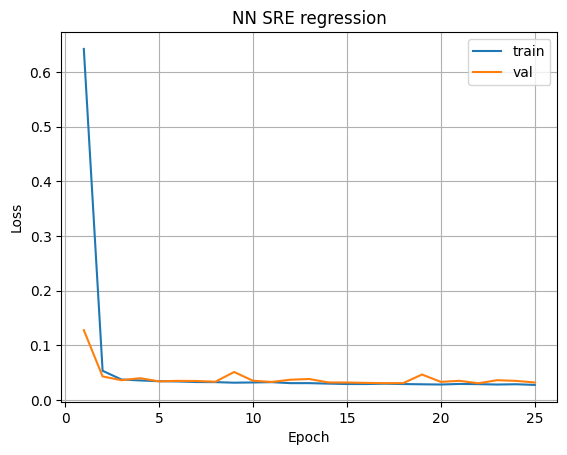

2026-05-14 10:53:02,665 - qqe.src.GNN.training.runners - INFO - Saved model checkpoint to ..\outputs\models\nn_huber_random.pt
2026-05-14 10:53:02,667 - scripts.train_model - INFO - Final test loss: 0.029264


In [13]:
training(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_type=model_type,
    model_hparams=default_model_hparams,
    train_hparams=default_train_hparams,
    training_data_dir=data_dir,
    show_progress=True,
    show_val_progress=False,
    log_every_n_batches=10,
    heartbeat_secs=60.0,
    epoch_time_warning_secs=600.0,
)

In [14]:
predictions(
    model_path="../outputs/models/nn_huber_random.pt",
    model_kind="nn",
    training_scope="family",
    loss_type="huber",
    model_family="random",
    dataset_root=data_dir,
    dataset_family="random",
    batch_size=32,
    global_feature_variant="binned",
    node_feature_backend_variant=None,
    plot_n_layers=10,
    plot_n_qubits=18,
    split_by_family=True,
    show_progress=True,
)

2026-05-14 10:54:07,048 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/nn_huber_random.pt
2026-05-14 10:54:34,499 - scripts.predictions - INFO - Found 124950 prediction files
Predicting (nn): 100%|██████████| 3905/3905 [02:50<00:00, 22.95batch/s]
2026-05-14 10:57:25,105 - scripts.predictions - INFO - Saved 124950 predictions to ../outputs/predictions/family/nn_predictions_random.csv
2026-05-14 10:57:25,235 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/family/nn_pred_layers_random.png
2026-05-14 10:57:25,364 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/family/nn_pred_qubits_random.png


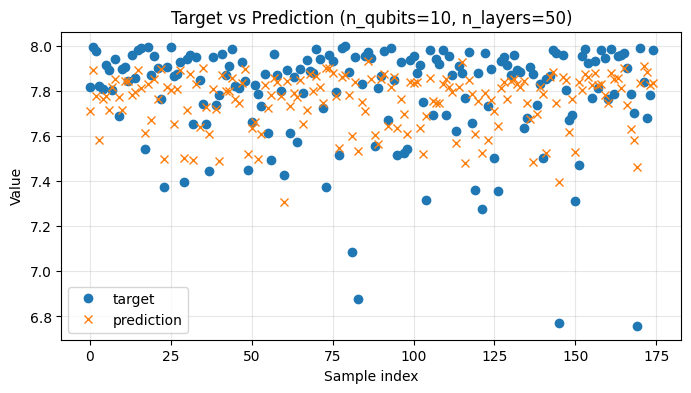

Pearson r = 0.6293


In [15]:
df = pd.read_csv("../outputs/predictions/family/nn_predictions_random.csv")

cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    df[col] = df[col].apply(to_scalar).astype(int)

view_correlation(
    df,
    nq=10,
    nl=50,
    col_x="target",
    col_y="prediction",
)

### Test runner function

#### GNN

In [8]:
model_type="gnn"
epochs = 25
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/identity_dataset"
model_save_path = "../outputs/models/identity_random_gnn.pt"

In [9]:
default_model_hparams = {
    "gnn_hidden": 32,
    "gnn_heads": 4,
    "global_hidden": 128,
    "reg_hidden": 128,
    "num_layers": 2,
    "dropout_rate": 0.10,
}

default_train_hparams = {
    "weight_decay": 0.00025,
    "grad_clip": 0.04,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

2026-05-14 13:19:46,452 - qqe.src.GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=huber
2026-05-14 13:19:46,453 - qqe.src.GNN.training.runners - INFO - Training configuration done.
2026-05-14 13:19:46,453 - qqe.src.GNN.training.runners - INFO - Collecting data paths...
2026-05-14 13:21:30,922 - qqe.src.GNN.training.runners - INFO - Found 35700 data paths.
2026-05-14 13:21:30,923 - qqe.src.GNN.training.runners - INFO - Data paths collected.
2026-05-14 13:21:30,924 - qqe.src.GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-05-14 13:23:09,444 - qqe.src.GNN.training.runners - INFO - Loaders and model built.
2026-05-14 13:23:09,445 - qqe.src.GNN.training.runners - INFO - Starting training...
2026-05-14 13:23:09,665 - qqe.src.GNN.training.train - INFO - -------- EPOCH 001 --------


Epoch 1/25:  65%|██████▌   | 523/804 [01:00<00:33,  8.33it/s, loss=0.0001, graphs=16768]

2026-05-14 13:24:09,724 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 524/804 | loss 0.000096 | elapsed 60.1s | graphs 16768


2026-05-14 13:24:41,905 - qqe.src.GNN.training.train - INFO - Training complete (92.2s) | running validation...


2026-05-14 13:24:50,903 - qqe.src.GNN.training.train - INFO - Losses | train 0.000081 | val 0.000030 | lr 1.00e-04 | time train=92.2s val=9.0s total=101.2s
2026-05-14 13:24:50,906 - qqe.src.GNN.training.train - INFO - -------- EPOCH 002 --------


...

2026-05-14 13:51:43,087 - qqe.src.GNN.training.train - INFO - Losses | train 0.000034 | val 0.000028 | lr 5.00e-05 | time train=86.1s val=8.9s total=95.0s
2026-05-14 13:51:43,088 - qqe.src.GNN.training.train - INFO - -------- EPOCH 018 --------


Epoch 18/25:  69%|██████▉   | 554/804 [01:00<00:26,  9.61it/s, loss=0.0000, graphs=17760]

2026-05-14 13:52:43,158 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 18 batch 555/804 | loss 0.000034 | elapsed 60.1s | graphs 17760


2026-05-14 13:53:09,372 - qqe.src.GNN.training.train - INFO - Training complete (86.3s) | running validation...


2026-05-14 13:53:18,507 - qqe.src.GNN.training.train - INFO - Losses | train 0.000034 | val 0.000029 | lr 5.00e-05 | time train=86.3s val=9.1s total=95.4s
2026-05-14 13:53:18,508 - qqe.src.GNN.training.train - INFO - Early stopping at epoch 018 | best val 0.000028 | patience exhausted (10/10)
2026-05-14 13:53:45,702 - qqe.src.GNN.training.runners - INFO - Training complete.


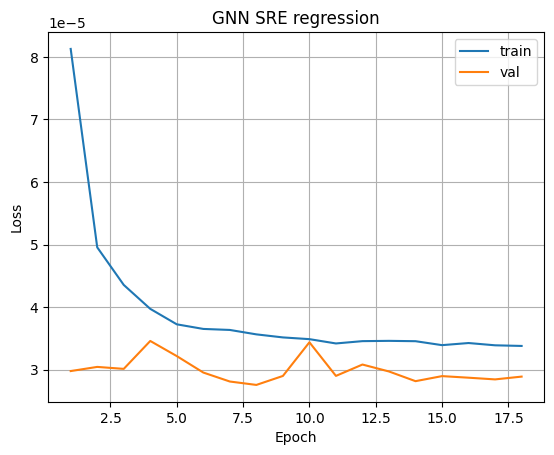

2026-05-14 13:53:46,003 - qqe.src.GNN.training.runners - INFO - Saved model checkpoint to ../outputs/models/identity_random_gnn.pt
2026-05-14 13:53:46,007 - scripts.train_model - INFO - Final test loss: 0.000029
2026-05-14 13:53:46,008 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/identity_random_gnn.pt
2026-05-14 13:54:28,535 - scripts.predictions - INFO - Found 124950 prediction files
Predicting (gnn): 100%|██████████| 3905/3905 [13:12<00:00,  4.93batch/s]
2026-05-14 14:07:52,723 - scripts.predictions - INFO - Saved 124950 predictions to ../outputs/predictions/family/gnn_predictions_random.csv
2026-05-14 14:07:52,982 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/family/gnn_pred_layers_random.png
2026-05-14 14:07:53,224 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/family/gnn_pred_qubits_random.png


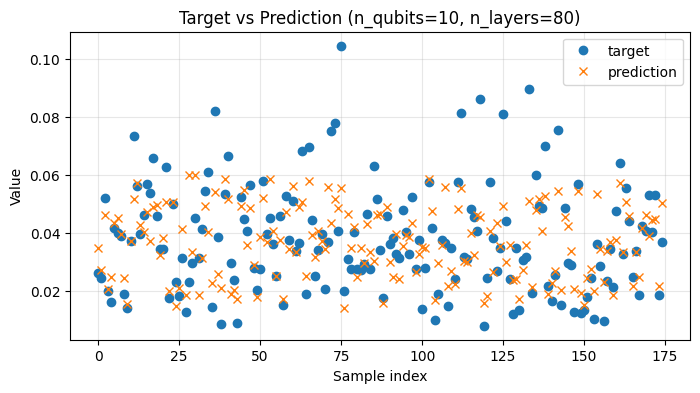

Pearson r = 0.7672


In [11]:
run(
    model_type=model_type,
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_hparams=default_model_hparams,
    train_hparams=default_train_hparams,
    training_data_dir=data_dir,
    model_save_path=model_save_path,
)

2026-05-15 14:16:49,754 - qqe.src.GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=clifford | loss_type=huber
2026-05-15 14:16:49,754 - qqe.src.GNN.training.runners - INFO - Training configuration done.
2026-05-15 14:16:49,756 - qqe.src.GNN.training.runners - INFO - Collecting data paths...
2026-05-15 14:18:51,676 - qqe.src.GNN.training.runners - INFO - Found 35700 data paths.
2026-05-15 14:18:51,676 - qqe.src.GNN.training.runners - INFO - Data paths collected.
2026-05-15 14:18:51,677 - qqe.src.GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-05-15 14:19:49,765 - qqe.src.GNN.training.runners - INFO - Loaders and model built.
2026-05-15 14:19:49,765 - qqe.src.GNN.training.runners - INFO - Starting training...
2026-05-15 14:19:49,770 - qqe.src.GNN.training.train - INFO - -------- EPOCH 001 --------


2026-05-15 14:20:39,013 - qqe.src.GNN.training.train - INFO - Training complete (49.2s) | running validation...


2026-05-15 14:20:43,352 - qqe.src.GNN.training.train - INFO - Losses | train 0.608991 | val 0.340803 | lr 1.00e-04 | time train=49.2s val=4.3s total=53.6s
2026-05-15 14:20:43,353 - qqe.src.GNN.training.train - INFO - -------- EPOCH 002 --------


2026-05-15 14:21:34,397 - qqe.src.GNN.training.train - INFO - Training complete (51.0s) | running validation...


2026-05-15 14:21:38,841 - qqe.src.GNN.training.train - INFO - Losses | train 0.417741 | val 0.456468 | lr 1.00e-04 | time train=51.0s val=4.4s total=55.5s
2026-05-15 14:21:38,842 - qqe.src.GNN.training.train - INFO - -------- EPOCH 003 --------


...

2026-05-15 14:32:21,581 - qqe.src.GNN.training.train - INFO - Losses | train 0.316525 | val 0.319577 | lr 5.00e-05 | time train=54.5s val=4.5s total=58.9s
2026-05-15 14:32:21,581 - qqe.src.GNN.training.train - INFO - -------- EPOCH 015 --------


2026-05-15 14:33:12,440 - qqe.src.GNN.training.train - INFO - Training complete (50.9s) | running validation...


2026-05-15 14:33:16,773 - qqe.src.GNN.training.train - INFO - Losses | train 0.316101 | val 0.317809 | lr 5.00e-05 | time train=50.9s val=4.3s total=55.2s
2026-05-15 14:33:16,773 - qqe.src.GNN.training.train - INFO - -------- EPOCH 016 --------


2026-05-15 14:34:06,745 - qqe.src.GNN.training.train - INFO - Training complete (50.0s) | running validation...


2026-05-15 14:34:11,271 - qqe.src.GNN.training.train - INFO - Losses | train 0.317270 | val 0.313690 | lr 5.00e-05 | time train=50.0s val=4.5s total=54.5s
2026-05-15 14:34:11,272 - qqe.src.GNN.training.train - INFO - Early stopping at epoch 016 | best val 0.291446 | patience exhausted (10/10)
2026-05-15 14:34:25,656 - qqe.src.GNN.training.runners - INFO - Training complete.


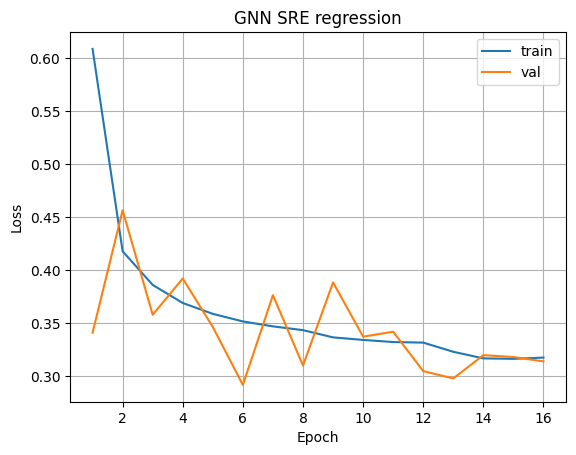

2026-05-15 14:34:25,772 - qqe.src.GNN.training.runners - INFO - Saved model checkpoint to ../outputs/models/clifford_model_gnn.pt
2026-05-15 14:34:25,774 - scripts.train_model - INFO - Final test loss: 0.289424
2026-05-15 14:34:25,775 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/clifford_model_gnn.pt
2026-05-15 14:34:57,801 - scripts.predictions - INFO - Found 124950 prediction files
Predicting (gnn): 100%|██████████| 3905/3905 [04:56<00:00, 13.17batch/s]
2026-05-15 14:40:02,610 - scripts.predictions - INFO - Saved 124950 predictions to ../outputs/predictions/family/gnn_predictions_clifford.csv
2026-05-15 14:40:02,798 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/family/gnn_pred_layers_clifford.png
2026-05-15 14:40:02,979 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/family/gnn_pred_qubits_clifford.png


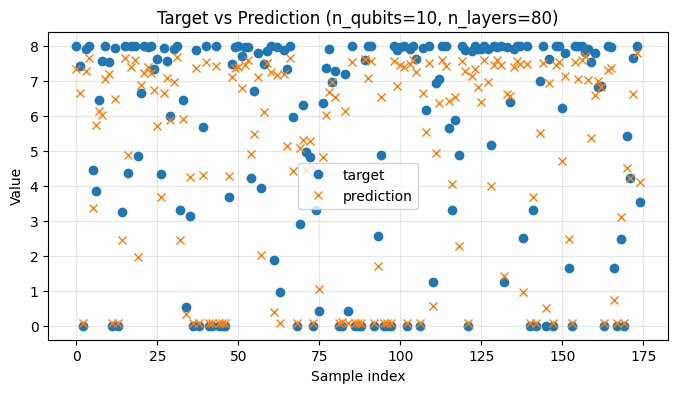

Pearson r = 0.9738


In [24]:
model_type="gnn"
epochs = 30
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "clifford"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/dataset"
model_save_path = "../outputs/models/clifford_model_gnn.pt"

default_model_hparams = {
    "gnn_hidden": 16,
    "gnn_heads": 6,
    "global_hidden": 128,
    "reg_hidden": 128,
    "num_layers": 3,
    "dropout_rate": 0.10,
}

default_train_hparams = {
    "weight_decay": 0.0003,
    "grad_clip": 0.04,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

run(
    model_type=model_type,
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_hparams=default_model_hparams,
    train_hparams=default_train_hparams,
    training_data_dir=data_dir,
    model_save_path=model_save_path,
)

2026-05-15 15:09:50,659 - qqe.src.GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=haar | loss_type=huber
2026-05-15 15:09:50,661 - qqe.src.GNN.training.runners - INFO - Training configuration done.
2026-05-15 15:09:50,661 - qqe.src.GNN.training.runners - INFO - Collecting data paths...
2026-05-15 15:11:45,290 - qqe.src.GNN.training.runners - INFO - Found 35700 data paths.
2026-05-15 15:11:45,292 - qqe.src.GNN.training.runners - INFO - Data paths collected.
2026-05-15 15:11:45,292 - qqe.src.GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-05-15 15:12:45,279 - qqe.src.GNN.training.runners - INFO - Loaders and model built.
2026-05-15 15:12:45,281 - qqe.src.GNN.training.runners - INFO - Starting training...
2026-05-15 15:12:45,284 - qqe.src.GNN.training.train - INFO - -------- EPOCH 001 --------


2026-05-15 15:13:43,629 - qqe.src.GNN.training.train - INFO - Training complete (58.3s) | running validation...


2026-05-15 15:13:49,962 - qqe.src.GNN.training.train - INFO - Losses | train 0.724800 | val 0.431319 | lr 1.00e-04 | time train=58.3s val=6.3s total=64.7s
2026-05-15 15:13:49,965 - qqe.src.GNN.training.train - INFO - -------- EPOCH 002 --------


Epoch 2/30:  89%|████████▉ | 719/804 [01:00<00:06, 12.91it/s, loss=0.4763, graphs=23072]

2026-05-15 15:14:50,028 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 2 batch 721/804 | loss 0.476297 | elapsed 60.1s | graphs 23072


...

2026-05-15 15:47:11,497 - qqe.src.GNN.training.train - INFO - Losses | train 0.135938 | val 0.090955 | lr 2.50e-05 | time train=79.4s val=6.1s total=85.5s
2026-05-15 15:47:11,498 - qqe.src.GNN.training.train - INFO - -------- EPOCH 030 --------


Epoch 30/30:  75%|███████▌  | 604/804 [01:00<00:19, 10.34it/s, loss=0.1369, graphs=19360]

2026-05-15 15:48:11,585 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 30 batch 605/804 | loss 0.136931 | elapsed 60.1s | graphs 19360


2026-05-15 15:48:30,363 - qqe.src.GNN.training.train - INFO - Training complete (78.9s) | running validation...


2026-05-15 15:48:37,056 - qqe.src.GNN.training.train - INFO - Losses | train 0.136375 | val 0.070080 | lr 2.50e-05 | time train=78.9s val=6.7s total=85.6s
2026-05-15 15:48:58,883 - qqe.src.GNN.training.runners - INFO - Training complete.


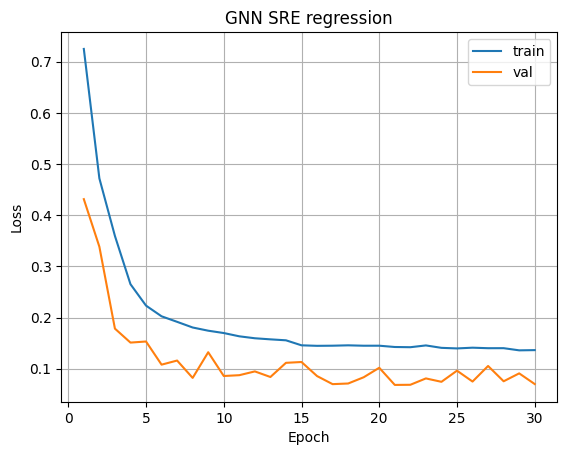

2026-05-15 15:48:59,036 - qqe.src.GNN.training.runners - INFO - Saved model checkpoint to ../outputs/models/quansistor_model_gnn.pt
2026-05-15 15:48:59,040 - scripts.train_model - INFO - Final test loss: 0.066875
2026-05-15 15:48:59,041 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/quansistor_model_gnn.pt
2026-05-15 15:49:44,662 - scripts.predictions - INFO - Found 124950 prediction files
Predicting (gnn): 100%|██████████| 3905/3905 [08:48<00:00,  7.39batch/s]
2026-05-15 15:58:49,242 - scripts.predictions - INFO - Saved 124950 predictions to ../outputs/predictions/family/gnn_predictions_haar.csv
2026-05-15 15:58:49,527 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/family/gnn_pred_layers_haar.png
2026-05-15 15:58:49,809 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/family/gnn_pred_qubits_haar.png


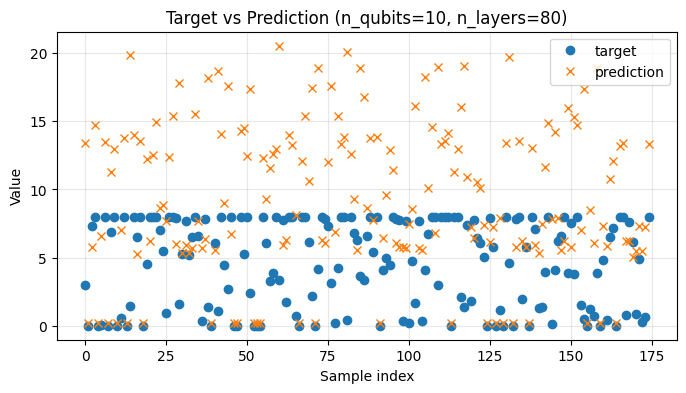

Pearson r = 0.3801


In [27]:
model_type="gnn"
epochs = 30
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "haar"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/dataset"
model_save_path = "../outputs/models/quansistor_model_gnn.pt"

default_model_hparams = {
    "gnn_hidden": 16,
    "gnn_heads": 6,
    "global_hidden": 128,
    "reg_hidden": 128,
    "num_layers": 3,
    "dropout_rate": 0.10,
}

default_train_hparams = {
    "weight_decay": 0.0003,
    "grad_clip": 0.04,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

run(
    model_type=model_type,
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_hparams=default_model_hparams,
    train_hparams=default_train_hparams,
    training_data_dir=data_dir,
    model_save_path=model_save_path,
)

#### NN

In [12]:
model_type="nn"
epochs = 25
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/identity_dataset"
model_save_path = "../outputs/models/identity_random_nn.pt"

In [ ]:
default_model_hparams = {
    "hidden_dim": 128,
    "dropout_rate": 0.0,
}

default_train_hparams = {
    "weight_decay": 1e-3,
    "grad_clip": 5.0,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

2026-05-14 14:08:14,083 - qqe.src.GNN.training.runners - INFO - Starting training | model_type=nn | training_mode=per_family | family=random | loss_type=huber
2026-05-14 14:08:14,084 - qqe.src.GNN.training.runners - INFO - Training configuration done.
2026-05-14 14:08:14,084 - qqe.src.GNN.training.runners - INFO - Collecting data paths...
2026-05-14 14:10:07,363 - qqe.src.GNN.training.runners - INFO - Found 35700 data paths.
2026-05-14 14:10:07,365 - qqe.src.GNN.training.runners - INFO - Data paths collected.
2026-05-14 14:10:07,365 - qqe.src.GNN.training.runners - INFO - Building loaders and model for model_type=nn...
2026-05-14 14:10:46,561 - qqe.src.GNN.training.runners - INFO - Loaders and model built.
2026-05-14 14:10:46,562 - qqe.src.GNN.training.runners - INFO - Starting training...
2026-05-14 14:10:46,564 - qqe.src.GNN.training.train - INFO - -------- EPOCH 001 --------


Epoch 1/25:  96%|█████████▌| 772/804 [01:00<00:02, 13.67it/s, loss=0.0001, graphs=24768]

2026-05-14 14:11:46,622 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 774/804 | loss 0.000103 | elapsed 60.1s | graphs 24768


2026-05-14 14:11:48,881 - qqe.src.GNN.training.train - INFO - Training complete (62.3s) | running validation...


2026-05-14 14:11:55,190 - qqe.src.GNN.training.train - INFO - Losses | train 0.000101 | val 0.000031 | lr 1.00e-04 | time train=62.3s val=6.3s total=68.6s
2026-05-14 14:11:55,192 - qqe.src.GNN.training.train - INFO - -------- EPOCH 002 --------


...

2026-05-14 14:23:05,986 - qqe.src.GNN.training.train - INFO - Losses | train 0.000032 | val 0.000029 | lr 5.00e-05 | time train=59.1s val=6.0s total=65.1s
2026-05-14 14:23:05,988 - qqe.src.GNN.training.train - INFO - -------- EPOCH 012 --------


2026-05-14 14:24:05,245 - qqe.src.GNN.training.train - INFO - Training complete (59.3s) | running validation...


2026-05-14 14:24:11,310 - qqe.src.GNN.training.train - INFO - Losses | train 0.000032 | val 0.000029 | lr 5.00e-05 | time train=59.3s val=6.1s total=65.3s
2026-05-14 14:24:11,312 - qqe.src.GNN.training.train - INFO - -------- EPOCH 013 --------


2026-05-14 14:25:10,459 - qqe.src.GNN.training.train - INFO - Training complete (59.1s) | running validation...


2026-05-14 14:25:16,552 - qqe.src.GNN.training.train - INFO - Losses | train 0.000032 | val 0.000030 | lr 5.00e-05 | time train=59.1s val=6.1s total=65.2s
2026-05-14 14:25:16,552 - qqe.src.GNN.training.train - INFO - Early stopping at epoch 013 | best val 0.000026 | patience exhausted (10/10)
2026-05-14 14:25:31,859 - qqe.src.GNN.training.runners - INFO - Training complete.


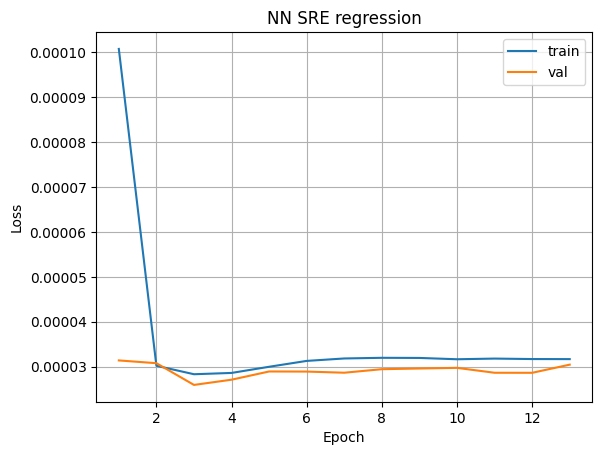

2026-05-14 14:25:32,005 - qqe.src.GNN.training.runners - INFO - Saved model checkpoint to ../outputs/models/identity_random_nn.pt
2026-05-14 14:25:32,009 - scripts.train_model - INFO - Final test loss: 0.000027
2026-05-14 14:25:32,010 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/identity_random_nn.pt
2026-05-14 14:26:07,918 - scripts.predictions - INFO - Found 124950 prediction files
Predicting (nn): 100%|██████████| 3905/3905 [03:48<00:00, 17.10batch/s]
2026-05-14 14:29:56,790 - scripts.predictions - INFO - Saved 124950 predictions to ../outputs/predictions/family/nn_predictions_random.csv
2026-05-14 14:29:56,956 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/family/nn_pred_layers_random.png
2026-05-14 14:29:57,111 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/family/nn_pred_qubits_random.png


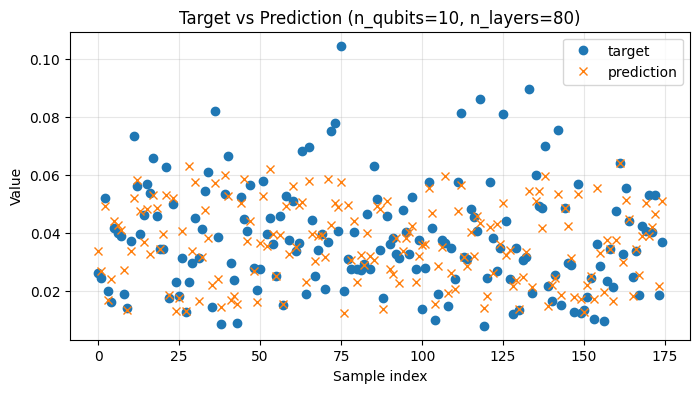

Pearson r = 0.7641


In [14]:
run(
    model_type=model_type,
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_hparams=default_model_hparams,
    train_hparams=default_train_hparams,
    training_data_dir=data_dir,
    model_save_path=model_save_path,
)

#### Regressor

In [8]:
model_type="regressor"
epochs = 25
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/identity_dataset"
model_save_path = "../outputs/models/identity_random_regressor.pt"

In [9]:
default_model_hparams = {
    "hidden_dim": 128,
    "dropout_rate": 0.0,
}

default_train_hparams = {
    "weight_decay": 1e-3,
    "grad_clip": 5.0,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

2026-05-14 14:44:58,356 - qqe.src.GNN.training.runners - INFO - Starting training | model_type=regressor | training_mode=per_family | family=random | loss_type=huber
2026-05-14 14:44:58,357 - qqe.src.GNN.training.runners - INFO - Training configuration done.
2026-05-14 14:44:58,357 - qqe.src.GNN.training.runners - INFO - Collecting data paths...
2026-05-14 14:47:08,084 - qqe.src.GNN.training.runners - INFO - Found 35700 data paths.
2026-05-14 14:47:08,085 - qqe.src.GNN.training.runners - INFO - Data paths collected.
2026-05-14 14:47:08,085 - qqe.src.GNN.training.runners - INFO - Building loaders and model for model_type=regressor...
2026-05-14 14:47:53,944 - qqe.src.GNN.training.runners - INFO - Loaders and model built.
2026-05-14 14:47:53,946 - qqe.src.GNN.training.runners - INFO - Starting training...
2026-05-14 14:47:53,947 - qqe.src.GNN.training.train - INFO - -------- EPOCH 001 --------


Epoch 1/25:  93%|█████████▎| 744/804 [01:00<00:04, 13.49it/s, loss=0.0058, graphs=23840]

2026-05-14 14:48:54,018 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 745/804 | loss 0.005759 | elapsed 60.1s | graphs 23840


2026-05-14 14:48:58,477 - qqe.src.GNN.training.train - INFO - Training complete (64.5s) | running validation...


2026-05-14 14:49:05,095 - qqe.src.GNN.training.train - INFO - Losses | train 0.005346 | val 0.000065 | lr 1.00e-04 | time train=64.5s val=6.6s total=71.1s
2026-05-14 14:49:05,096 - qqe.src.GNN.training.train - INFO - -------- EPOCH 002 --------


...

2026-05-14 15:13:28,461 - qqe.src.GNN.training.train - INFO - Losses | train 0.000028 | val 0.000026 | lr 5.00e-05 | time train=60.2s val=6.5s total=66.7s
2026-05-14 15:13:28,462 - qqe.src.GNN.training.train - INFO - -------- EPOCH 024 --------


Epoch 24/25: 100%|█████████▉| 800/804 [01:00<00:00, 13.38it/s, loss=0.0000, graphs=25664]

2026-05-14 15:14:28,495 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 24 batch 802/804 | loss 0.000028 | elapsed 60.0s | graphs 25664


2026-05-14 15:14:28,600 - qqe.src.GNN.training.train - INFO - Training complete (60.1s) | running validation...


2026-05-14 15:14:34,773 - qqe.src.GNN.training.train - INFO - Losses | train 0.000028 | val 0.000027 | lr 5.00e-05 | time train=60.1s val=6.2s total=66.3s
2026-05-14 15:14:34,775 - qqe.src.GNN.training.train - INFO - Early stopping at epoch 024 | best val 0.000025 | patience exhausted (10/10)
2026-05-14 15:14:51,108 - qqe.src.GNN.training.runners - INFO - Training complete.


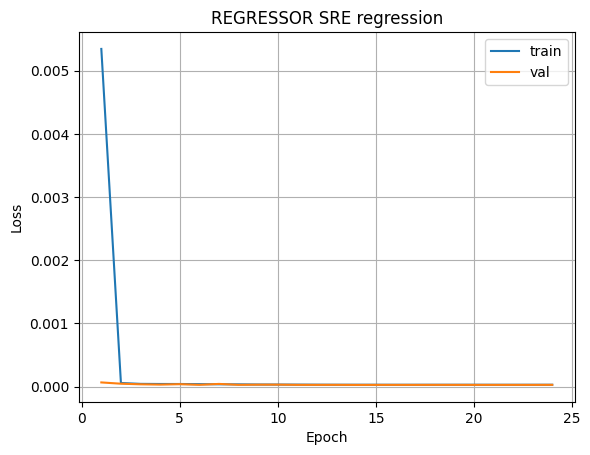

2026-05-14 15:14:51,237 - qqe.src.GNN.training.runners - INFO - Saved model checkpoint to ../outputs/models/identity_random_regressor.pt
2026-05-14 15:14:51,240 - scripts.train_model - INFO - Final test loss: 0.000027


ValueError: model_kind must be 'gnn' or 'nn'

In [17]:
run(
    model_type=model_type,
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_hparams=default_model_hparams,
    train_hparams=default_train_hparams,
    training_data_dir=data_dir,
    model_save_path=model_save_path,
)

2026-05-15 11:16:05,009 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/identity_random_regressor.pt
2026-05-15 11:16:41,596 - scripts.predictions - INFO - Found 124950 prediction files
Predicting (nn): 100%|██████████| 3905/3905 [14:26<00:00,  4.51batch/s]
2026-05-15 11:31:08,593 - scripts.predictions - INFO - Saved 124950 predictions to ../outputs/predictions/family/regressor_predictions_random.csv
2026-05-15 11:31:08,845 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/family/regressor_pred_layers_random.png
2026-05-15 11:31:08,973 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/family/regressor_pred_qubits_random.png


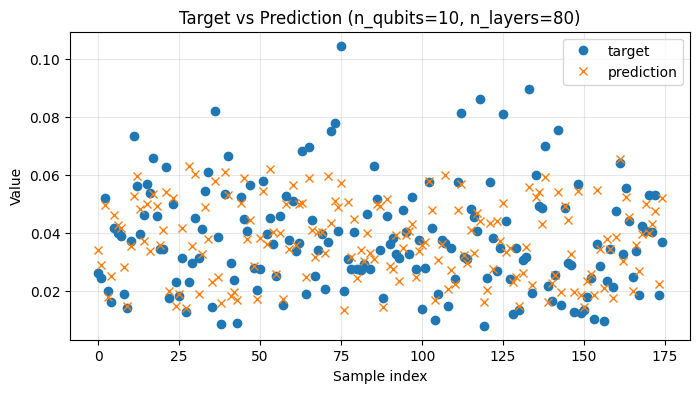

Pearson r = 0.7614


In [15]:
training_mode = "family"
predictions(
    model_path="../outputs/models/identity_random_regressor.pt",
    model_kind=model_type,
    training_scope=training_mode,
    loss_type=loss_type,
    model_family=family,
    dataset_root=data_dir,
    dataset_family=family,
    batch_size=batch_size,
    global_feature_variant="binned",
    node_feature_backend_variant=None,
    plot_n_layers=10,
    plot_n_qubits=18,
    split_by_family=True,
    show_progress=True,
)

df = pd.read_csv(f"../outputs/predictions/{training_mode}/{model_type}_predictions_{family}.csv")
cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    df[col] = df[col].apply(to_scalar).astype(int)
view_correlation(
    df,
    nq=10,
    nl=80,
    col_x="target",
    col_y="prediction",
)

## General dataset

#### GNN

In [16]:
model_type="gnn"
epochs = 25
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/general_dataset"
model_save_path = "../outputs/models/general_random_gnn.pt"

In [17]:
default_model_hparams = {
    "gnn_hidden": 32,
    "gnn_heads": 4,
    "global_hidden": 128,
    "reg_hidden": 128,
    "num_layers": 2,
    "dropout_rate": 0.10,
}

default_train_hparams = {
    "weight_decay": 0.00025,
    "grad_clip": 0.04,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

2026-05-15 11:38:50,059 - qqe.src.GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=huber
2026-05-15 11:38:50,060 - qqe.src.GNN.training.runners - INFO - Training configuration done.
2026-05-15 11:38:50,061 - qqe.src.GNN.training.runners - INFO - Collecting data paths...
2026-05-15 11:51:08,762 - qqe.src.GNN.training.runners - INFO - Found 35700 data paths.
2026-05-15 11:51:08,763 - qqe.src.GNN.training.runners - INFO - Data paths collected.
2026-05-15 11:51:08,764 - qqe.src.GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-05-15 11:52:52,687 - qqe.src.GNN.training.runners - INFO - Loaders and model built.
2026-05-15 11:52:52,688 - qqe.src.GNN.training.runners - INFO - Starting training...
2026-05-15 11:52:52,691 - qqe.src.GNN.training.train - INFO - -------- EPOCH 001 --------


Epoch 1/25:  75%|███████▌  | 603/804 [01:00<00:19, 10.11it/s, loss=1.0101, graphs=19328]

2026-05-15 11:53:52,764 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 604/804 | loss 1.010089 | elapsed 60.1s | graphs 19328


2026-05-15 11:54:11,877 - qqe.src.GNN.training.train - INFO - Training complete (79.2s) | running validation...


2026-05-15 11:54:20,228 - qqe.src.GNN.training.train - INFO - Losses | train 0.836225 | val 0.145855 | lr 1.00e-04 | time train=79.2s val=8.4s total=87.5s
2026-05-15 11:54:20,230 - qqe.src.GNN.training.train - INFO - -------- EPOCH 002 --------


...

2026-05-15 12:21:27,667 - qqe.src.GNN.training.train - INFO - Losses | train 0.132604 | val 0.046686 | lr 5.00e-05 | time train=85.7s val=8.8s total=94.5s
2026-05-15 12:21:27,668 - qqe.src.GNN.training.train - INFO - -------- EPOCH 020 --------


Epoch 20/25:  72%|███████▏  | 578/804 [01:00<00:23,  9.64it/s, loss=0.1342, graphs=18528]

2026-05-15 12:22:27,673 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 20 batch 579/804 | loss 0.134154 | elapsed 60.0s | graphs 18528


2026-05-15 12:22:51,805 - qqe.src.GNN.training.train - INFO - Training complete (84.1s) | running validation...


2026-05-15 12:23:00,737 - qqe.src.GNN.training.train - INFO - Losses | train 0.133264 | val 0.068641 | lr 5.00e-05 | time train=84.1s val=8.9s total=93.1s
2026-05-15 12:23:00,738 - qqe.src.GNN.training.train - INFO - Early stopping at epoch 020 | best val 0.039464 | patience exhausted (10/10)
2026-05-15 12:23:24,997 - qqe.src.GNN.training.runners - INFO - Training complete.


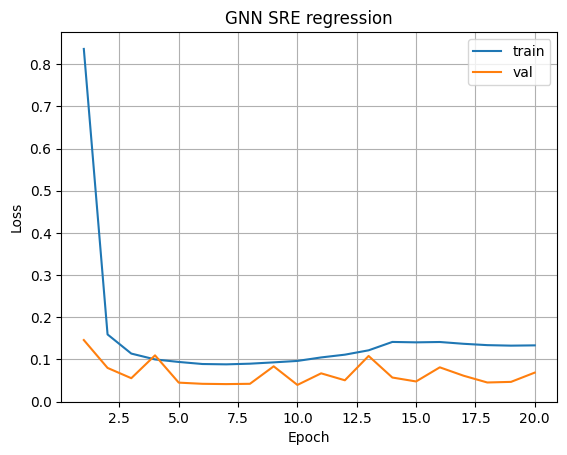

2026-05-15 12:23:25,120 - qqe.src.GNN.training.runners - INFO - Saved model checkpoint to ../outputs/models/general_random_gnn.pt
2026-05-15 12:23:25,122 - scripts.train_model - INFO - Final test loss: 0.038096
2026-05-15 12:23:25,124 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/general_random_gnn.pt
2026-05-15 12:23:58,759 - scripts.predictions - INFO - Found 124950 prediction files
Predicting (gnn): 100%|██████████| 3905/3905 [11:54<00:00,  5.47batch/s]
2026-05-15 12:36:02,536 - scripts.predictions - INFO - Saved 124950 predictions to ../outputs/predictions/family/gnn_predictions_random.csv
2026-05-15 12:36:02,724 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/family/gnn_pred_layers_random.png
2026-05-15 12:36:02,926 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/family/gnn_pred_qubits_random.png


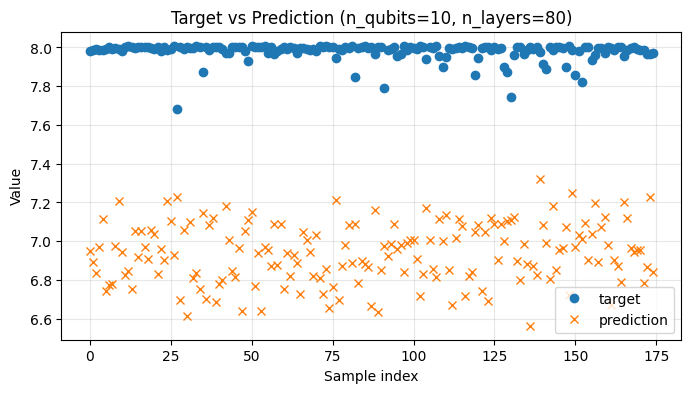

Pearson r = -0.3826


In [18]:
run(
    model_type=model_type,
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_hparams=default_model_hparams,
    train_hparams=default_train_hparams,
    training_data_dir=data_dir,
    model_save_path=model_save_path,
)

#### NN

In [19]:
model_type="nn"
epochs = 25
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/general_dataset"
model_save_path = "../outputs/models/general_random_gnn.pt"

default_model_hparams = {
    "hidden_dim": 128,
    "dropout_rate": 0.0,
}

default_train_hparams = {
    "weight_decay": 1e-3,
    "grad_clip": 5.0,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

2026-05-15 12:36:19,297 - qqe.src.GNN.training.runners - INFO - Starting training | model_type=nn | training_mode=per_family | family=random | loss_type=huber
2026-05-15 12:36:19,299 - qqe.src.GNN.training.runners - INFO - Training configuration done.
2026-05-15 12:36:19,299 - qqe.src.GNN.training.runners - INFO - Collecting data paths...
2026-05-15 12:37:46,865 - qqe.src.GNN.training.runners - INFO - Found 35700 data paths.
2026-05-15 12:37:46,866 - qqe.src.GNN.training.runners - INFO - Data paths collected.
2026-05-15 12:37:46,866 - qqe.src.GNN.training.runners - INFO - Building loaders and model for model_type=nn...
2026-05-15 12:38:21,567 - qqe.src.GNN.training.runners - INFO - Loaders and model built.
2026-05-15 12:38:21,569 - qqe.src.GNN.training.runners - INFO - Starting training...
2026-05-15 12:38:21,571 - qqe.src.GNN.training.train - INFO - -------- EPOCH 001 --------


2026-05-15 12:39:17,427 - qqe.src.GNN.training.train - INFO - Training complete (55.9s) | running validation...


2026-05-15 12:39:23,412 - qqe.src.GNN.training.train - INFO - Losses | train 0.621299 | val 0.128929 | lr 1.00e-04 | time train=55.9s val=6.0s total=61.8s
2026-05-15 12:39:23,413 - qqe.src.GNN.training.train - INFO - -------- EPOCH 002 --------


2026-05-15 12:40:16,581 - qqe.src.GNN.training.train - INFO - Training complete (53.2s) | running validation...


2026-05-15 12:40:22,075 - qqe.src.GNN.training.train - INFO - Losses | train 0.049748 | val 0.041162 | lr 1.00e-04 | time train=53.2s val=5.5s total=58.7s
2026-05-15 12:40:22,076 - qqe.src.GNN.training.train - INFO - -------- EPOCH 003 --------


...

2026-05-15 13:01:48,639 - qqe.src.GNN.training.train - INFO - Losses | train 0.027345 | val 0.031002 | lr 5.00e-05 | time train=54.8s val=5.8s total=60.7s
2026-05-15 13:01:48,640 - qqe.src.GNN.training.train - INFO - -------- EPOCH 024 --------


2026-05-15 13:02:43,484 - qqe.src.GNN.training.train - INFO - Training complete (54.8s) | running validation...


2026-05-15 13:02:49,288 - qqe.src.GNN.training.train - INFO - Losses | train 0.026769 | val 0.033023 | lr 5.00e-05 | time train=54.8s val=5.8s total=60.6s
2026-05-15 13:02:49,289 - qqe.src.GNN.training.train - INFO - -------- EPOCH 025 --------


2026-05-15 13:03:44,204 - qqe.src.GNN.training.train - INFO - Training complete (54.9s) | running validation...


2026-05-15 13:03:50,046 - qqe.src.GNN.training.train - INFO - Losses | train 0.026688 | val 0.030758 | lr 5.00e-05 | time train=54.9s val=5.8s total=60.8s
2026-05-15 13:04:05,420 - qqe.src.GNN.training.runners - INFO - Training complete.


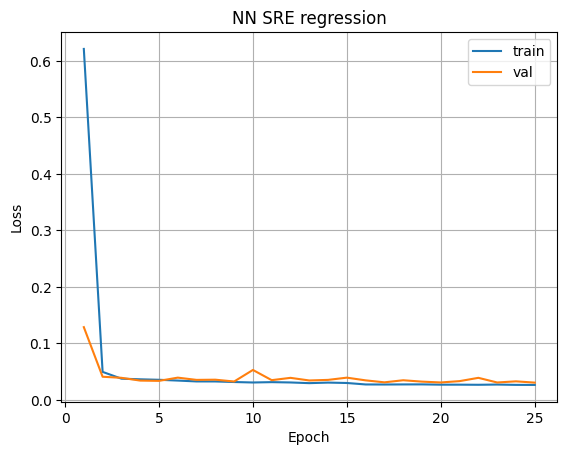

2026-05-15 13:04:05,541 - qqe.src.GNN.training.runners - INFO - Saved model checkpoint to ../outputs/models/general_random_gnn.pt
2026-05-15 13:04:05,542 - scripts.train_model - INFO - Final test loss: 0.028593
2026-05-15 13:04:05,544 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/general_random_gnn.pt
2026-05-15 13:04:35,776 - scripts.predictions - INFO - Found 124950 prediction files
Predicting (nn): 100%|██████████| 3905/3905 [03:34<00:00, 18.24batch/s]
2026-05-15 13:08:10,309 - scripts.predictions - INFO - Saved 124950 predictions to ../outputs/predictions/family/nn_predictions_random.csv
2026-05-15 13:08:10,430 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/family/nn_pred_layers_random.png
2026-05-15 13:08:10,558 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/family/nn_pred_qubits_random.png


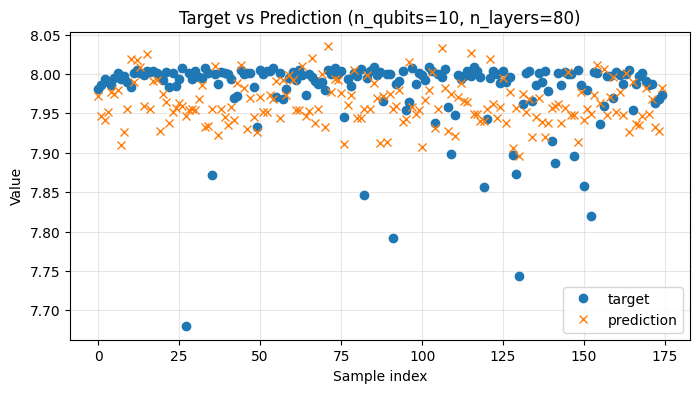

Pearson r = 0.2330


In [20]:
run(
    model_type=model_type,
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_hparams=default_model_hparams,
    train_hparams=default_train_hparams,
    training_data_dir=data_dir,
    model_save_path=model_save_path,
)

#### Regressor

In [21]:
model_type="regressor"
epochs = 25
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/general_dataset"
model_save_path = "../outputs/models/general_random_gnn.pt"

default_model_hparams = {
    "hidden_dim": 128,
    "dropout_rate": 0.0,
}

default_train_hparams = {
    "weight_decay": 1e-3,
    "grad_clip": 5.0,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

2026-05-15 13:14:00,765 - qqe.src.GNN.training.runners - INFO - Starting training | model_type=regressor | training_mode=per_family | family=random | loss_type=huber
2026-05-15 13:14:00,765 - qqe.src.GNN.training.runners - INFO - Training configuration done.
2026-05-15 13:14:00,766 - qqe.src.GNN.training.runners - INFO - Collecting data paths...
2026-05-15 13:15:18,405 - qqe.src.GNN.training.runners - INFO - Found 35700 data paths.
2026-05-15 13:15:18,406 - qqe.src.GNN.training.runners - INFO - Data paths collected.
2026-05-15 13:15:18,407 - qqe.src.GNN.training.runners - INFO - Building loaders and model for model_type=regressor...
2026-05-15 13:15:51,738 - qqe.src.GNN.training.runners - INFO - Loaders and model built.
2026-05-15 13:15:51,738 - qqe.src.GNN.training.runners - INFO - Starting training...
2026-05-15 13:15:51,741 - qqe.src.GNN.training.train - INFO - -------- EPOCH 001 --------


2026-05-15 13:16:40,430 - qqe.src.GNN.training.train - INFO - Training complete (48.7s) | running validation...


2026-05-15 13:16:45,502 - qqe.src.GNN.training.train - INFO - Losses | train 0.641924 | val 0.252015 | lr 1.00e-04 | time train=48.7s val=5.1s total=53.8s
2026-05-15 13:16:45,503 - qqe.src.GNN.training.train - INFO - -------- EPOCH 002 --------


2026-05-15 13:17:34,327 - qqe.src.GNN.training.train - INFO - Training complete (48.8s) | running validation...


2026-05-15 13:17:39,419 - qqe.src.GNN.training.train - INFO - Losses | train 0.093041 | val 0.043369 | lr 1.00e-04 | time train=48.8s val=5.1s total=53.9s
2026-05-15 13:17:39,420 - qqe.src.GNN.training.train - INFO - -------- EPOCH 003 --------


...

2026-05-15 13:37:39,590 - qqe.src.GNN.training.train - INFO - Losses | train 0.027620 | val 0.033334 | lr 1.00e-04 | time train=50.4s val=5.2s total=55.7s
2026-05-15 13:37:39,591 - qqe.src.GNN.training.train - INFO - -------- EPOCH 024 --------


2026-05-15 13:38:29,945 - qqe.src.GNN.training.train - INFO - Training complete (50.4s) | running validation...


2026-05-15 13:38:35,133 - qqe.src.GNN.training.train - INFO - Losses | train 0.027469 | val 0.033400 | lr 1.00e-04 | time train=50.4s val=5.2s total=55.5s
2026-05-15 13:38:35,134 - qqe.src.GNN.training.train - INFO - -------- EPOCH 025 --------


2026-05-15 13:39:25,335 - qqe.src.GNN.training.train - INFO - Training complete (50.2s) | running validation...


2026-05-15 13:39:30,934 - qqe.src.GNN.training.train - INFO - Losses | train 0.027303 | val 0.033592 | lr 5.00e-05 | time train=50.2s val=5.6s total=55.8s
2026-05-15 13:39:45,036 - qqe.src.GNN.training.runners - INFO - Training complete.


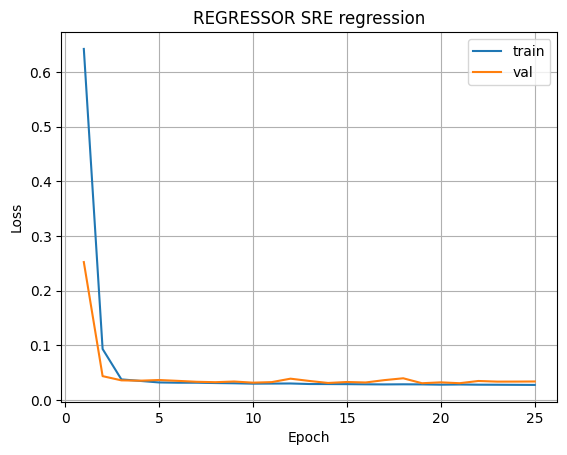

2026-05-15 13:39:45,155 - qqe.src.GNN.training.runners - INFO - Saved model checkpoint to ../outputs/models/general_random_gnn.pt
2026-05-15 13:39:45,157 - scripts.train_model - INFO - Final test loss: 0.028813
2026-05-15 13:39:45,159 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/general_random_gnn.pt
2026-05-15 13:40:15,796 - scripts.predictions - INFO - Found 124950 prediction files
Predicting (nn): 100%|██████████| 3905/3905 [03:21<00:00, 19.36batch/s]
2026-05-15 13:43:37,894 - scripts.predictions - INFO - Saved 124950 predictions to ../outputs/predictions/family/regressor_predictions_random.csv
2026-05-15 13:43:38,021 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/family/regressor_pred_layers_random.png
2026-05-15 13:43:38,147 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/family/regressor_pred_qubits_random.png


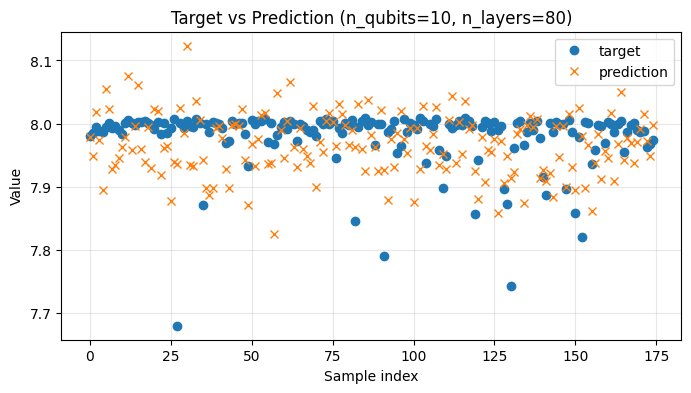

Pearson r = 0.3031


In [22]:
run(
    model_type=model_type,
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_hparams=default_model_hparams,
    train_hparams=default_train_hparams,
    training_data_dir=data_dir,
    model_save_path=model_save_path,
)